# Proyecto 1: plantilla de entrega

**Ciencia de Datos, Sección A** · Sesión 12 · 1 de septiembre de 2026

Entrega: **viernes 11 de septiembre** · 10 puntos

---

Esta es la plantilla del Proyecto 1: las secciones ya están creadas y las celdas de código están vacías. Trabajen encima de este archivo, renómbrenlo como `P1-<su apellido>.ipynb` y borren las instrucciones en cursiva antes de entregar.

**Autor(es):**

**Dataset elegido:**

### Rúbrica resumida

| Criterio | Pts | Qué buscamos |
|---|---|---|
| Pregunta y datos | 2 | Pregunta clara, provenance del dataset |
| EDA | 3 | Hallazgos, no galería de gráficas |
| Features | 2 | Cada decisión justificada, sin leakage |
| Baseline | 2 | Validación correcta, métrica adecuada |
| Límites | 1 | Qué no puede concluirse con estos datos |

## 1. Pregunta y contexto

Este proyecto busca responder la siguiente pregunta: ¿Qué diferencias en las estadísticas de juego, sin incluir goles ni resultado final, se relacionan con que un equipo visitante gane un partido de la fase liga de la UEFA Champions League 2025/26? Se analizarán estadísticas registradas durante el partido, como posesión, tiros al arco y atajadas, para comparar los partidos que terminaron en victoria visitante con los que terminaron en empate o victoria local.

El análisis puede ser útil para entender qué patrones aparecen con más frecuencia en las victorias como visitante. Por ejemplo, permitirá observar si estos equipos suelen generar más tiros al arco, tener menos posesión pero aprovechar mejor sus oportunidades, o mostrar un mejor desempeño defensivo. El objetivo no es probar que una estadística cause la victoria ni predecir el resultado antes del partido, sino describir las relaciones encontradas en los 144 partidos disponibles de la fase liga.

**Pregunta:** ¿Qué diferencias en las estadísticas de juego, sin incluir goles ni resultado final, se relacionan con que un equipo visitante gane un partido de la fase liga de la UEFA Champions League 2025/26?

**Tipo de problema:** clasificación binaria.

**Variable objetivo:** `away_win`, toma el valor de 1 cuando los goles del visitante son mayores que los del local, y 0 cuando el visitante empata o pierde.

## 2. Los datos

**Fuente:** dataset *Champions League Matches 2025-2026*, publicado por John Tocci en Kaggle y obtenido desde la API pública de Kaggle. URL: https://www.kaggle.com/datasets/johntocci/champions-league-matches-2025-2026

**Fecha de descarga:** se registra automáticamente cada vez que se ejecuta la celda de carga. La versión consultada fue actualizada por el autor el 30 de enero de 2026.

**Licencia:** CC0, Public Domain, según los metadatos del dataset en Kaggle.

**Unidad de observación:** cada fila válida representa un partido de la fase liga. El archivo contiene 151 filas, de las cuales 7 están completamente vacías, por lo que se trabajará con 144 partidos válidos disputados entre septiembre de 2025 y enero de 2026.

**Diccionario breve de variables:** `date`, fecha del partido, `home_team` y `away_team`, equipos local y visitante, `score`, marcador final, `result`, resultado del partido, `home_possession` y `away_possession`, porcentaje de posesión, `home_shots_on_target` y `away_shots_on_target`, tiros al arco y tiros totales guardados como texto, `home_saves` y `away_saves`, atajadas guardadas como texto, las columnas terminadas en `_pct`, porcentajes calculados por la fuente. `score`, `result` y `winner` se usarán solo para construir o revisar la variable objetivo, no como predictores.

El dataset no incluye faltas, tarjetas ni una variable de etapa. Por esa razón, el análisis se concentrará en posesión, tiros al arco, atajadas y sus porcentajes.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
import requests
from zipfile import ZipFile

RANDOM_STATE = 42

# Descargar el archivo desde Kaggle y cargar el CSV
URL_DATASET = (
    "https://www.kaggle.com/api/v1/datasets/download/"
    "johntocci/champions-league-matches-2025-2026"
)

respuesta = requests.get(URL_DATASET, timeout=30)
print("Código de respuesta:", respuesta.status_code)

with ZipFile(io.BytesIO(respuesta.content)) as archivo_zip:
    print("Archivo descargado:", archivo_zip.namelist())
    with archivo_zip.open("champions_league_matches.csv") as archivo:
        df = pd.read_csv(archivo)

ficha = {
    "fuente": "Kaggle, Champions League Matches 2025-2026, John Tocci",
    "url": "https://www.kaggle.com/datasets/johntocci/champions-league-matches-2025-2026",
    "fecha_descarga": pd.Timestamp.now().strftime("%Y-%m-%d"),
    "licencia": "CC0: Public Domain",
    "filas_archivo": len(df),
    "columnas": len(df.columns),
}
ficha

Código de respuesta: 200
Archivo descargado: ['champions_league_matches.csv']


{'fuente': 'Kaggle, Champions League Matches 2025-2026, John Tocci',
 'url': 'https://www.kaggle.com/datasets/johntocci/champions-league-matches-2025-2026',
 'fecha_descarga': '2026-09-14',
 'licencia': 'CC0: Public Domain',
 'filas_archivo': 151,
 'columnas': 18}

## 3. Primer barrido

Se revisan la forma del DataFrame, los tipos de cada columna y algunos valores iniciales antes de limpiar o transformar los datos.

In [4]:
print("Forma del DataFrame:", df.shape)
df.info()
df.head()

Forma del DataFrame: (151, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      144 non-null    object 
 1   home_team                 144 non-null    object 
 2   away_team                 144 non-null    object 
 3   score                     144 non-null    object 
 4   venue                     144 non-null    object 
 5   referee                   144 non-null    object 
 6   home_possession           144 non-null    object 
 7   away_possession           144 non-null    object 
 8   home_shots_on_target      144 non-null    object 
 9   away_shots_on_target      144 non-null    object 
 10  home_saves                144 non-null    object 
 11  away_saves                144 non-null    object 
 12  home_shots_on_target_pct  144 non-null    float64
 13  away_shots_on_target_pct  144 non-

,date,home_team,away_team,score,venue,referee,home_possession,away_possession,home_shots_on_target,away_shots_on_target,home_saves,away_saves,home_shots_on_target_pct,away_shots_on_target_pct,home_saves_pct,away_saves_pct,result,winner
0,2025-09-16,PSV,Union SG,1–3,Philips Stadion,Anthony Taylor,63%,37%,3 of 10,8 of 18,4 of 8,2 of 3,30.0,44.4,50.0,66.7,Away Win,Union SG
1,2025-09-16,Athletic Club,Arsenal,0–2,San Mamés,Donatas Rumšas,38%,62%,2 of 11,6 of 11,4 of 6,2 of 2,18.2,54.5,66.7,100.0,Away Win,Arsenal
2,2025-09-16,Tottenham Hotspur,Villarreal,1–0,Tottenham Hotspur Stadium,Rade Obrenović,58%,42%,1 of 9,0 of 10,0 of 0,1 of 1,11.1,0.0,NaN,100.0,Home Win,Tottenham Hotspur
3,2025-09-16,Benfica,Qarabağ,2–3,Estádio do Sport Lisboa e Benfica,Erik Lambrechts,53%,47%,3 of 14,5 of 10,2 of 5,1 of 3,21.4,50.0,40.0,33.3,Away Win,Qarabağ
4,2025-09-16,Juventus,Dortmund,4–4,Allianz Stadium,François Letexier,52%,48%,7 of 19,5 of 10,1 of 5,3 of 7,36.8,50.0,20.0,42.9,Draw,Draw


In [5]:
print(df.describe())

print("\nResultado del partido:")
print(df["result"].value_counts(dropna=False))

print("\nFechas registradas:")
print(df["date"].value_counts(dropna=False).sort_index())

print("\nEquipos locales con más partidos:")
print(df["home_team"].value_counts(dropna=False).head(10))

       home_shots_on_target_pct  away_shots_on_target_pct  home_saves_pct  \
count                 144.00000                144.000000      141.000000   
mean                   37.35000                 38.147917       67.666667   
std                    14.27387                 17.319947       28.335847   
min                     6.20000                  0.000000        0.000000   
25%                    26.70000                 27.150000       50.000000   
50%                    36.80000                 35.300000       66.700000   
75%                    45.72500                 46.800000      100.000000   
max                    80.00000                100.000000      100.000000   

       away_saves_pct  
count      144.000000  
mean        65.104167  
std         25.537119  
min          0.000000  
25%         50.000000  
50%         66.700000  
75%         85.700000  
max        100.000000  

Resultado del partido:
result
Home Win    71
Away Win    48
Draw        25
NaN          7

**Observaciones del primer barrido:**

1. El archivo tiene 151 filas y 18 columnas. Siete filas están completamente vacías, por lo que los datos reales corresponden a 144 partidos de la fase liga.

2. Las columnas de posesión, tiros al arco y atajadas aparecen como texto, mientras que los porcentajes ya están como números. Antes de usarlas en el análisis será necesario convertir las estadísticas que están guardadas como texto.

3. Hay 48 victorias visitantes, 71 victorias locales y 25 empates. Por lo tanto, la clase `away_win` tendrá 48 casos positivos y 96 casos negativos, una diferencia que se debe considerar al evaluar el modelo.

## 4. Calidad de datos

Primero se identifica qué faltantes corresponden a filas sin información y cuáles aparecen en partidos reales. Las siete filas totalmente vacías no representan partidos, parecen espacios vacíos incluidos en el archivo de origen. Por eso se eliminan solo esas filas, sin usar un `dropna()` general.

Después de eliminar esas filas, quedan tres faltantes en `home_saves_pct`. En los tres partidos, `home_saves` es `0 of 0`, es decir, el equipo local no tuvo atajadas posibles y el porcentaje no se puede calcular. Este faltante es estructural y se parece a MAR, porque se explica por una variable observada. No se imputará un porcentaje inventado y esta columna no se usará como predictor.

Para los porcentajes numéricos se revisan outliers con la regla IQR. Un porcentaje alto de tiros al arco es posible en un partido real, por lo que un valor extremo no se eliminará si permanece entre 0 y 100 y no parece un error de captura.

In [6]:
print("Faltantes antes de limpiar:")
print(df.isna().sum())

filas_vacias = df.isna().all(axis=1)
print("\nFilas completamente vacías:", filas_vacias.sum())

# Solo se eliminan filas que no contienen ningún dato de un partido
df = df.loc[~filas_vacias].copy()

faltantes = pd.DataFrame({
    "cantidad": df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(2),
})
print("\nFaltantes después de eliminar las filas vacías:")
print(faltantes[faltantes["cantidad"] > 0])

print("\nPartidos con home_saves_pct faltante:")
print(df.loc[df["home_saves_pct"].isna(), [
    "date", "home_team", "away_team", "home_saves", "home_saves_pct"
]])

Faltantes antes de limpiar:
date                         7
home_team                    7
away_team                    7
score                        7
venue                        7
referee                      7
home_possession              7
away_possession              7
home_shots_on_target         7
away_shots_on_target         7
home_saves                   7
away_saves                   7
home_shots_on_target_pct     7
away_shots_on_target_pct     7
home_saves_pct              10
away_saves_pct               7
result                       7
winner                       7
dtype: int64

Filas completamente vacías: 7

Faltantes después de eliminar las filas vacías:
                cantidad  porcentaje
home_saves_pct         3        2.08

Partidos con home_saves_pct faltante:
           date          home_team    away_team home_saves  home_saves_pct
2    2025-09-16  Tottenham Hotspur   Villarreal     0 of 0             NaN
95   2025-12-09      Bayern Munich  Sporting CP     0 of 0

In [7]:
print("Filas duplicadas exactas:", df.duplicated().sum())
print("Partidos duplicados por fecha y equipos:",
      df.duplicated(subset=["date", "home_team", "away_team"]).sum())

numericas = df.select_dtypes("number")
resumen_outliers = []

for columna in numericas:
    x = df[columna].dropna()
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    bajo, alto = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    es_outlier = (x < bajo) | (x > alto)

    resumen_outliers.append({
        "variable": columna,
        "límite inferior": round(bajo, 2),
        "límite superior": round(alto, 2),
        "outliers": int(es_outlier.sum()),
        "valores detectados": x[es_outlier].tolist(),
    })

pd.DataFrame(resumen_outliers)

Filas duplicadas exactas: 0
Partidos duplicados por fecha y equipos: 0


,variable,límite inferior,límite superior,outliers,valores detectados
0,home_shots_on_target_pct,-1.84,74.26,2,"[75.0, 80.0]"
1,away_shots_on_target_pct,-2.33,76.28,4,"[90.9, 100.0, 77.8, 100.0]"
2,home_saves_pct,-25.00,175.00,0,[]
3,away_saves_pct,-3.55,139.25,0,[]


**Decisiones tomadas y su justificación:**

| Problema | Filas o columnas afectadas | Qué hicimos | Por qué |
|---|---|---|---|
| Filas completamente vacías | 7 filas | Se eliminaron con una máscara que identifica filas sin ningún dato. | No representan partidos y parecen espacios vacíos agregados por el archivo de origen. |
| Faltantes en `home_saves_pct` | 3 partidos | Se conservaron los partidos, no se imputó el porcentaje y la columna no se usará como predictor. | En los tres casos `home_saves` es `0 of 0`, por lo que no hubo atajadas posibles y el porcentaje no está definido. Es un faltante estructural, explicado por información observada. |
| Duplicados | Ninguno | No se eliminó ninguna fila por duplicado. | No hay filas repetidas ni partidos repetidos al comparar fecha, equipo local y equipo visitante. |
| Outliers en porcentajes de tiros al arco | 2 valores locales y 4 valores visitantes según IQR | Se conservaron. | Los valores están entre 75% y 100%, un rango válido para un porcentaje y posible en partidos reales. Son rendimiento poco común, no errores evidentes. |

## 5. Análisis exploratorio

Se exploran la distribución de la variable objetivo y las relaciones entre las estadísticas del partido y una victoria visitante. Las columnas de goles se usan solo para crear `away_win`; no se incluyen en las gráficas de predictores ni se usarán en el modelo.

away_win
0    96
1    48
Name: count, dtype: int64


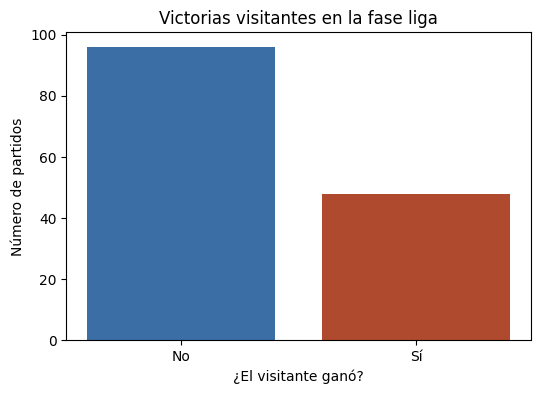

In [8]:
# Convertir las estadísticas de texto a números para el EDA
# str.replace quita el símbolo %, str.split separa textos como 3 of 10
marcador = df["score"].str.split("–", expand=True)
df["home_goals"] = marcador[0].astype(int)
df["away_goals"] = marcador[1].astype(int)
df["away_win"] = (df["away_goals"] > df["home_goals"]).astype(int)

for lado in ["home", "away"]:
    df[f"{lado}_possession_num"] = (
        df[f"{lado}_possession"].str.replace("%", "", regex=False).astype(float)
    )

    tiros = df[f"{lado}_shots_on_target"].str.split(" of ", expand=True)
    df[f"{lado}_shots_on_target_num"] = tiros[0].astype(float)
    df[f"{lado}_shots_num"] = tiros[1].astype(float)

    atajadas = df[f"{lado}_saves"].str.split(" of ", expand=True)
    df[f"{lado}_saves_num"] = atajadas[0].astype(float)

conteo_away_win = df["away_win"].value_counts().sort_index()
print(conteo_away_win)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["No", "Sí"], conteo_away_win.values, color=["#3A6EA5", "#B04A2E"])
ax.set_xlabel("¿El visitante ganó?")
ax.set_ylabel("Número de partidos")
ax.set_title("Victorias visitantes en la fase liga")
plt.show()

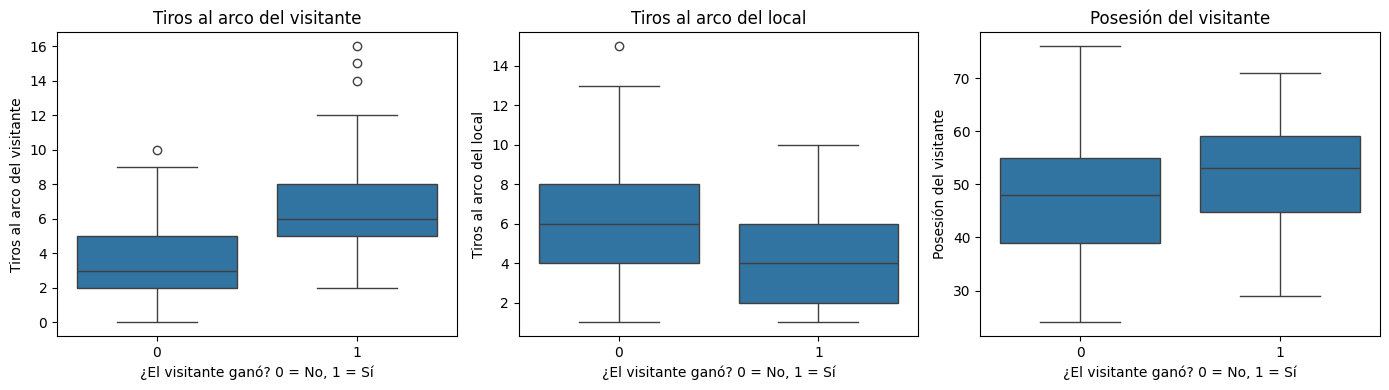

          away_shots_on_target_num  home_shots_on_target_num  \
away_win                                                       
0                              3.0                       6.0   
1                              6.0                       4.0   

          away_possession_num  
away_win                       
0                        48.0  
1                        53.0  


In [9]:
variables_eda = [
    "away_shots_on_target_num",
    "home_shots_on_target_num",
    "away_possession_num",
]
titulos = [
    "Tiros al arco del visitante",
    "Tiros al arco del local",
    "Posesión del visitante",
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, variable, titulo in zip(axes, variables_eda, titulos):
    sns.boxplot(data=df, x="away_win", y=variable, ax=ax)
    ax.set_xlabel("¿El visitante ganó? 0 = No, 1 = Sí")
    ax.set_ylabel(titulo)
    ax.set_title(titulo)

fig.tight_layout()
plt.show()

print(df.groupby("away_win")[variables_eda].median())

away_win                    1.000000
away_shots_on_target_num    0.529929
away_shots_on_target_pct    0.360695
away_shots_num              0.325271
home_saves_num              0.237714
away_saves_pct              0.207180
away_possession_num         0.149324
home_possession_num        -0.148774
away_saves_num             -0.182598
home_shots_num             -0.267358
home_shots_on_target_pct   -0.297751
home_shots_on_target_num   -0.377916
Name: away_win, dtype: float64


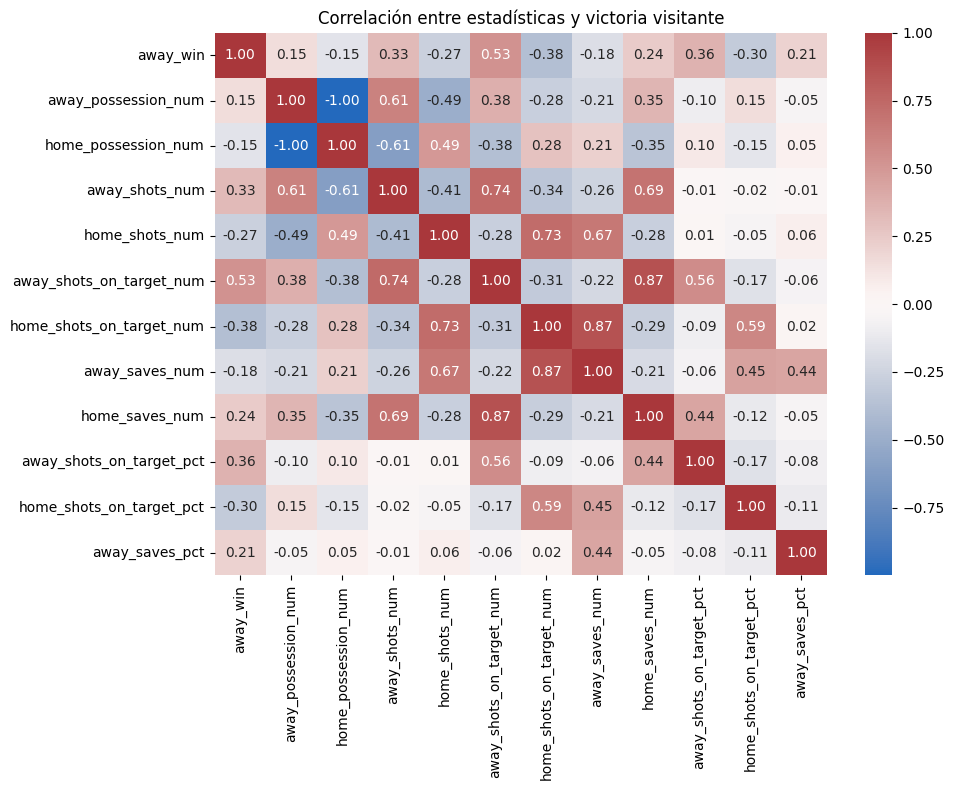

In [10]:
columnas_corr = [
    "away_win",
    "away_possession_num", "home_possession_num",
    "away_shots_num", "home_shots_num",
    "away_shots_on_target_num", "home_shots_on_target_num",
    "away_saves_num", "home_saves_num",
    "away_shots_on_target_pct", "home_shots_on_target_pct",
    "away_saves_pct",
]

correlaciones = df[columnas_corr].corr()
print(correlaciones["away_win"].sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlaciones, annot=True, fmt=".2f", cmap="vlag", ax=ax)
ax.set_title("Correlación entre estadísticas y victoria visitante")
fig.tight_layout()
plt.show()

**Hallazgos del EDA (numerados, con la gráfica que los respalda):**

1. La gráfica de distribución muestra 48 victorias visitantes y 96 casos en los que el visitante empató o perdió. Una victoria visitante ocurrió en un tercio de los partidos, por lo que accuracy por sí sola puede ser engañosa si no se compara con el baseline.

2. En los boxplots, los visitantes que ganaron tuvieron una mediana de 6 tiros al arco, frente a 3 cuando no ganaron. Al mismo tiempo, los locales enfrentados a una victoria visitante tuvieron una mediana de 4 tiros al arco, frente a 6 en los demás partidos.

3. La matriz de correlación muestra que `away_shots_on_target_num` tiene la relación positiva más alta con `away_win`, aproximadamente 0.53. La posesión del visitante tiene una relación positiva menor, aproximadamente 0.15, por lo que tener más posesión parece menos relacionado con ganar que generar tiros al arco. Estas relaciones no prueban causalidad.

## 6. Feature engineering

Se usarán cuatro diferencias, estadística del visitante menos la misma estadística del local. Así cada valor es fácil de leer: un número positivo favorece al visitante y uno negativo favorece al local.

No se usarán goles, marcador, `result` ni `winner` como features porque revelan el resultado. Tampoco se usará `home_saves_pct`, ya que tiene tres valores no aplicables. La partición train/test se hace antes de ajustar el escalamiento.

In [11]:
from sklearn.model_selection import train_test_split

df["possession_diff"] = df["away_possession_num"] - df["home_possession_num"]
df["shots_diff"] = df["away_shots_num"] - df["home_shots_num"]
df["shots_on_target_diff"] = (
    df["away_shots_on_target_num"] - df["home_shots_on_target_num"]
)
df["saves_diff"] = df["away_saves_num"] - df["home_saves_num"]

features = [
    "possession_diff",
    "shots_diff",
    "shots_on_target_diff",
    "saves_diff",
]

X = df[features]
y = df["away_win"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, y_train.value_counts().sort_index().to_dict())
print("Test:", X_test.shape, y_test.value_counts().sort_index().to_dict())

Train: (115, 4) {0: 77, 1: 38}
Test: (29, 4) {0: 19, 1: 10}


In [12]:
# El scaler se ajusta cuando el pipeline recibe X_train
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

preproceso = Pipeline([
    ("scaler", StandardScaler()),
])

**Features y su justificación:**

| Feature | Cómo se construyó | Por qué debería ayudar |
|---|---|---|
| `possession_diff` | Posesión del visitante menos posesión del local. | Resume cuál equipo tuvo más balón sin usar dos columnas muy parecidas. |
| `shots_diff` | Tiros totales del visitante menos tiros totales del local. | Más intentos pueden reflejar una mayor presencia ofensiva. |
| `shots_on_target_diff` | Tiros al arco del visitante menos tiros al arco del local. | El EDA mostró que los tiros al arco del visitante se relacionan con `away_win`. |
| `saves_diff` | Atajadas del visitante menos atajadas del local. | Aporta contexto sobre las intervenciones de ambos porteros, aunque se interpretará con cuidado porque también depende de los tiros recibidos. |

Las cuatro features se escalan con `StandardScaler` dentro de un pipeline. k-NN usa distancias, por lo que sin escalamiento una variable con números más grandes tendría más peso.

## 7. Modelo baseline

Primero se usa un modelo trivial que siempre predice la clase más frecuente, visitante no gana. Después se compara contra k-NN con 5 vecinos, el mismo valor usado en clase.

In [13]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

,strategy,'most_frequent'
,random_state,None
,constant,None


In [14]:
from sklearn.neighbors import KNeighborsClassifier

modelo_knn = Pipeline([
    ("preproceso", preproceso),
    ("knn", KNeighborsClassifier(n_neighbors=5)),
])

modelo_knn.fit(X_train, y_train)

,steps,"[('preproceso', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True


    Modelo  Accuracy train  Accuracy test  Precision test  Recall test  \
0  Trivial           0.670          0.655           0.000          0.0   
1     k-NN           0.887          0.793           0.833          0.5   

   F1 test  
0    0.000  
1    0.625  


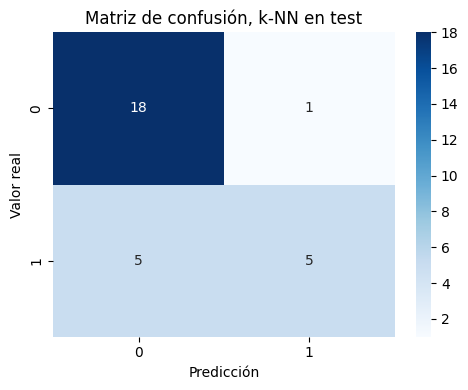

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

pred_baseline_train = baseline.predict(X_train)
pred_baseline_test = baseline.predict(X_test)
pred_knn_train = modelo_knn.predict(X_train)
pred_knn_test = modelo_knn.predict(X_test)

resultados_modelos = pd.DataFrame({
    "Modelo": ["Trivial", "k-NN"],
    "Accuracy train": [
        accuracy_score(y_train, pred_baseline_train),
        accuracy_score(y_train, pred_knn_train),
    ],
    "Accuracy test": [
        accuracy_score(y_test, pred_baseline_test),
        accuracy_score(y_test, pred_knn_test),
    ],
    "Precision test": [
        precision_score(y_test, pred_baseline_test, zero_division=0),
        precision_score(y_test, pred_knn_test, zero_division=0),
    ],
    "Recall test": [
        recall_score(y_test, pred_baseline_test, zero_division=0),
        recall_score(y_test, pred_knn_test, zero_division=0),
    ],
    "F1 test": [
        f1_score(y_test, pred_baseline_test, zero_division=0),
        f1_score(y_test, pred_knn_test, zero_division=0),
    ],
}).round(3)

print(resultados_modelos)

matriz = confusion_matrix(y_test, pred_knn_test)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_xlabel("Predicción")
ax.set_ylabel("Valor real")
ax.set_title("Matriz de confusión, k-NN en test")
fig.tight_layout()
plt.show()

**Resultados:**

| Modelo | Métrica en train | Métrica en test |
|---|---|---|
| Trivial | Accuracy: 0.670 | Accuracy: 0.655, precision: 0.000, recall: 0.000 |
| k-NN, 5 vecinos | Accuracy: 0.887 | Accuracy: 0.793, precision: 0.833, recall: 0.500, F1: 0.625 |

k-NN supera al baseline en accuracy de test por 0.138, aproximadamente 14 puntos porcentuales. El baseline no detecta ninguna victoria visitante porque siempre predice la clase mayoritaria. k-NN identifica 5 de las 10 victorias visitantes en test y se equivoca en 1 partido que no era victoria visitante. Es una mejora útil para explorar los patrones, pero el tamaño del test es pequeño y las estadísticas se conocen después del partido.

## 8. Conclusiones y límites

*Respondan la pregunta de la sección 1 con lo que encontraron. Después, un párrafo sobre lo que **no** se puede concluir: sesgos de la muestra, variables ausentes, correlaciones que no son causalidad, y en qué contexto este modelo dejaría de funcionar.*

**Respuesta a la pregunta:**

**Límites del análisis:**

**Qué haría falta para responderla mejor:**

## 9. Bitácora de colaboración con AI

*Según la política del curso: si usaron asistencia de AI, documenten en qué partes, qué les pidieron y qué verificaron ustedes. Si no la usaron, escríbanlo también.*

## Anexo: peer critique (se llena en clase)

**Revisor:**

1. ¿Entendí la pregunta del proyecto sin preguntarle al autor?
2. ¿Hay alguna gráfica o celda que yo borraría? ¿Cuál y por qué?
3. ¿Veo algún punto donde se pudo haber colado información del test?